# Mislabel Detection: 3-Model Consensus on Full Dataset

Deep analysis (notebook 09) revealed that many high-loss failure cases are actually **wrong ground-truth labels** rather than model errors. Before hyperparameter tuning, we need to clean the entire `foodsg-233_cleaned` dataset (~204K images).

**Approach**: Run all 3 trained models (ResNet50, ViT, ConvNeXt) on every image. Flag suspected mislabels where multiple models agree the image belongs to a different class than its ground-truth label.

**Tiers**:
- **Tier 1 (3/3 consensus)**: All 3 models predict the same class != ground truth. Very high confidence mislabels.
- **Tier 2 (2/3 consensus)**: 2 models agree on a class != ground truth. ConvNeXt must be one of the two. Average softmax confidence >= 0.5.

**Output**: CSVs compatible with `cleaning_results/duplicate_reviewer.py` for visual review.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import os
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from collections import Counter

from utils import Config, set_seed, get_val_transforms, FoodClassifier, load_class_mapping

set_seed(Config.SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
# ── Model configurations (same as 09_deep_analysis) ──
NUM_CLASSES = 233

MODELS = {
    'CNN (ResNet50)': {
        'name': 'resnet50',
        'checkpoint': 'checkpoints/sgfood233_resnet50/epoch=09-val_acc=0.7509.ckpt',
    },
    'ViT': {
        'name': 'vit_base_patch16_224',
        'checkpoint': 'checkpoints/sgfood233_vit_base_patch16_224/epoch=09-val_acc=0.8015.ckpt',
    },
    'ConvNeXt': {
        'name': 'convnext_base',
        'checkpoint': 'checkpoints/sgfood233_convnext_base/epoch=09-val_acc=0.8345.ckpt',
    },
}

# Load class mapping
id2label = load_class_mapping('checkpoints/sgfood233_resnet50/id2label.json')
label2id = {v: k for k, v in id2label.items()}
class_names = [id2label[i] for i in range(NUM_CLASSES)]
print(f"Loaded {len(class_names)} class names")

# Load all 3 models
models = {}
for display_name, config in MODELS.items():
    print(f"Loading {display_name}...")
    model = FoodClassifier.load_from_checkpoint(
        config['checkpoint'],
        backbone_name=config['name'],
        num_classes=NUM_CLASSES,
    )
    model.eval()
    model.to(device)
    models[display_name] = model

print("\nAll models loaded.")

Loaded 233 class names
Loading CNN (ResNet50)...
Loading ViT...
Loading ConvNeXt...

All models loaded.


In [3]:
# ── Load full foodsg-233_cleaned dataset ──
CLEANED_ROOT = "../foodsg-233_cleaned"

transforms = get_val_transforms()  # no augmentation, just resize + normalize
dataset = ImageFolder(CLEANED_ROOT, transform=transforms)
dataset_raw = ImageFolder(CLEANED_ROOT, transform=None)  # for visualization

# Verify class ordering matches model's expected ordering
assert dataset.classes == class_names, (
    f"Class ordering mismatch!\n"
    f"  ImageFolder first 5: {dataset.classes[:5]}\n"
    f"  Model first 5:       {class_names[:5]}"
)
print(f"Class ordering verified: {len(dataset.classes)} classes match.")

loader = DataLoader(
    dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)

print(f"Total samples: {len(dataset):,}")
print(f"Num classes:   {len(dataset.classes)}")
print(f"Batches:       {len(loader)}")

Class ordering verified: 233 classes match.
Total samples: 204,305
Num classes:   233
Batches:       3193


In [4]:
# ── Run inference for all 3 models ──
def get_all_predictions(model, dataloader, device):
    """Get predictions, true labels, and logits for all samples."""
    model.eval()
    all_preds = []
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Predicting"):
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_logits.append(logits.cpu())

    return (
        torch.cat(all_preds).numpy(),
        torch.cat(all_labels).numpy(),
        torch.cat(all_logits),
    )

predictions = {}
logits_all = {}

for name, model in models.items():
    print(f"\nRunning {name} on {len(dataset):,} images...")
    preds, labels, logits = get_all_predictions(model, loader, device)
    predictions[name] = preds
    logits_all[name] = logits

    accuracy = (preds == labels).mean()
    print(f"  Accuracy on full dataset: {accuracy:.4f}")

true_labels = labels  # same for all models
print(f"\nTotal samples: {len(true_labels):,}")


Running CNN (ResNet50) on 204,305 images...


Predicting:   0%|          | 0/3193 [00:10<?, ?it/s]

  Accuracy on full dataset: 0.8191

Running ViT on 204,305 images...


Predicting:   0%|          | 0/3193 [00:11<?, ?it/s]

  Accuracy on full dataset: 0.9495

Running ConvNeXt on 204,305 images...


Predicting:   0%|          | 0/3193 [00:11<?, ?it/s]

  Accuracy on full dataset: 0.9581

Total samples: 204,305


In [5]:
# ── Mislabel detection: Tier 1 + Tier 2 ──
cnn_preds = predictions['CNN (ResNet50)']
vit_preds = predictions['ViT']
convnext_preds = predictions['ConvNeXt']

# --- Tier 1: All 3 models agree on a class != ground truth ---
all_agree = (cnn_preds == vit_preds) & (vit_preds == convnext_preds)
wrong = cnn_preds != true_labels
tier1_mask = all_agree & wrong
tier1_indices = np.where(tier1_mask)[0]
tier1_predicted = cnn_preds[tier1_mask]  # all 3 agree, so any model's pred works

print(f"Tier 1 (3/3 consensus): {len(tier1_indices):,} suspected mislabels")

# --- Tier 2: 2/3 consensus, ConvNeXt must be one, avg softmax >= 0.5 ---
# Compute softmax confidences for the predicted class of each model
cnn_probs = F.softmax(logits_all['CNN (ResNet50)'], dim=1)
vit_probs = F.softmax(logits_all['ViT'], dim=1)
convnext_probs = F.softmax(logits_all['ConvNeXt'], dim=1)

tier2_indices = []
tier2_predicted = []
tier2_num_agree = []
tier2_confidence = []

for i in range(len(true_labels)):
    if tier1_mask[i]:
        continue  # already in Tier 1

    gt = true_labels[i]
    cp, vp, cnp = cnn_preds[i], vit_preds[i], convnext_preds[i]

    # Check ConvNeXt + ViT agree on class != gt
    if cnp == vp and cnp != gt:
        agreed_class = int(cnp)
        avg_conf = (convnext_probs[i, agreed_class].item() + vit_probs[i, agreed_class].item()) / 2
        if avg_conf >= 0.5:
            tier2_indices.append(i)
            tier2_predicted.append(agreed_class)
            tier2_num_agree.append(2)
            tier2_confidence.append(avg_conf)
            continue

    # Check ConvNeXt + CNN agree on class != gt
    if cnp == cp and cnp != gt:
        agreed_class = int(cnp)
        avg_conf = (convnext_probs[i, agreed_class].item() + cnn_probs[i, agreed_class].item()) / 2
        if avg_conf >= 0.5:
            tier2_indices.append(i)
            tier2_predicted.append(agreed_class)
            tier2_num_agree.append(2)
            tier2_confidence.append(avg_conf)

tier2_indices = np.array(tier2_indices)
tier2_predicted = np.array(tier2_predicted)
tier2_num_agree = np.array(tier2_num_agree)
tier2_confidence = np.array(tier2_confidence)

print(f"Tier 2 (2/3 consensus): {len(tier2_indices):,} suspected mislabels")
print(f"\nTotal flagged: {len(tier1_indices) + len(tier2_indices):,} / {len(true_labels):,} ({(len(tier1_indices) + len(tier2_indices)) / len(true_labels):.2%})")

Tier 1 (3/3 consensus): 2,217 suspected mislabels
Tier 2 (2/3 consensus): 2,293 suspected mislabels

Total flagged: 4,510 / 204,305 (2.21%)


In [6]:
# ── Summary statistics ──
print("=" * 70)
print("MISLABEL DETECTION SUMMARY")
print("=" * 70)
print(f"Total images scanned:  {len(true_labels):,}")
print(f"Tier 1 (3/3 agree):    {len(tier1_indices):,}")
print(f"Tier 2 (2/3 agree):    {len(tier2_indices):,}")
print(f"Combined:              {len(tier1_indices) + len(tier2_indices):,} "
      f"({(len(tier1_indices) + len(tier2_indices)) / len(true_labels):.2%})")

# Top 20 confusion pairs for Tier 1
print(f"\n--- Tier 1: Top 20 Confusion Pairs (label -> models say) ---")
tier1_pairs = Counter()
for idx, pred in zip(tier1_indices, tier1_predicted):
    gt_name = class_names[true_labels[idx]]
    pred_name = class_names[pred]
    tier1_pairs[(gt_name, pred_name)] += 1

for (gt, pred), count in tier1_pairs.most_common(20):
    print(f"  {gt:30s} -> {pred:30s}  ({count})")

# Top 20 confusion pairs for Tier 2
print(f"\n--- Tier 2: Top 20 Confusion Pairs (label -> models say) ---")
tier2_pairs = Counter()
for idx, pred in zip(tier2_indices, tier2_predicted):
    gt_name = class_names[true_labels[idx]]
    pred_name = class_names[pred]
    tier2_pairs[(gt_name, pred_name)] += 1

for (gt, pred), count in tier2_pairs.most_common(20):
    print(f"  {gt:30s} -> {pred:30s}  ({count})")

# Top 10 most-affected classes
print(f"\n--- Top 10 Most Affected Classes (Tier 1 + Tier 2) ---")
all_flagged_indices = np.concatenate([tier1_indices, tier2_indices])
affected_classes = Counter(true_labels[i] for i in all_flagged_indices)

# Count total per class for percentage
class_totals = Counter(true_labels)

for cls_idx, count in affected_classes.most_common(10):
    total = class_totals[cls_idx]
    print(f"  {class_names[cls_idx]:30s}  {count:4d} / {total:4d}  ({count/total:.1%})")

MISLABEL DETECTION SUMMARY
Total images scanned:  204,305
Tier 1 (3/3 agree):    2,217
Tier 2 (2/3 agree):    2,293
Combined:              4,510 (2.21%)

--- Tier 1: Top 20 Confusion Pairs (label -> models say) ---
  whole wheat                    -> whole grain bread               (25)
  char siew pau                  -> steamed buns                    (23)
  cream soup                     -> mushroom soup                   (19)
  steamed buns                   -> char siew pau                   (18)
  Lontong with sayur lodeh       -> lontong                         (17)
  Mee siam, fried                -> Bee hoon, goreng                (17)
  Seafood Noodles Soup           -> sliced fish soup                (17)
  chicken soup                   -> vegetable soup                  (16)
  fried chicken                  -> chicken wing                    (16)
  rock melon                     -> honeydew                        (16)
  Bee hoon, soto                 -> Mee soto           

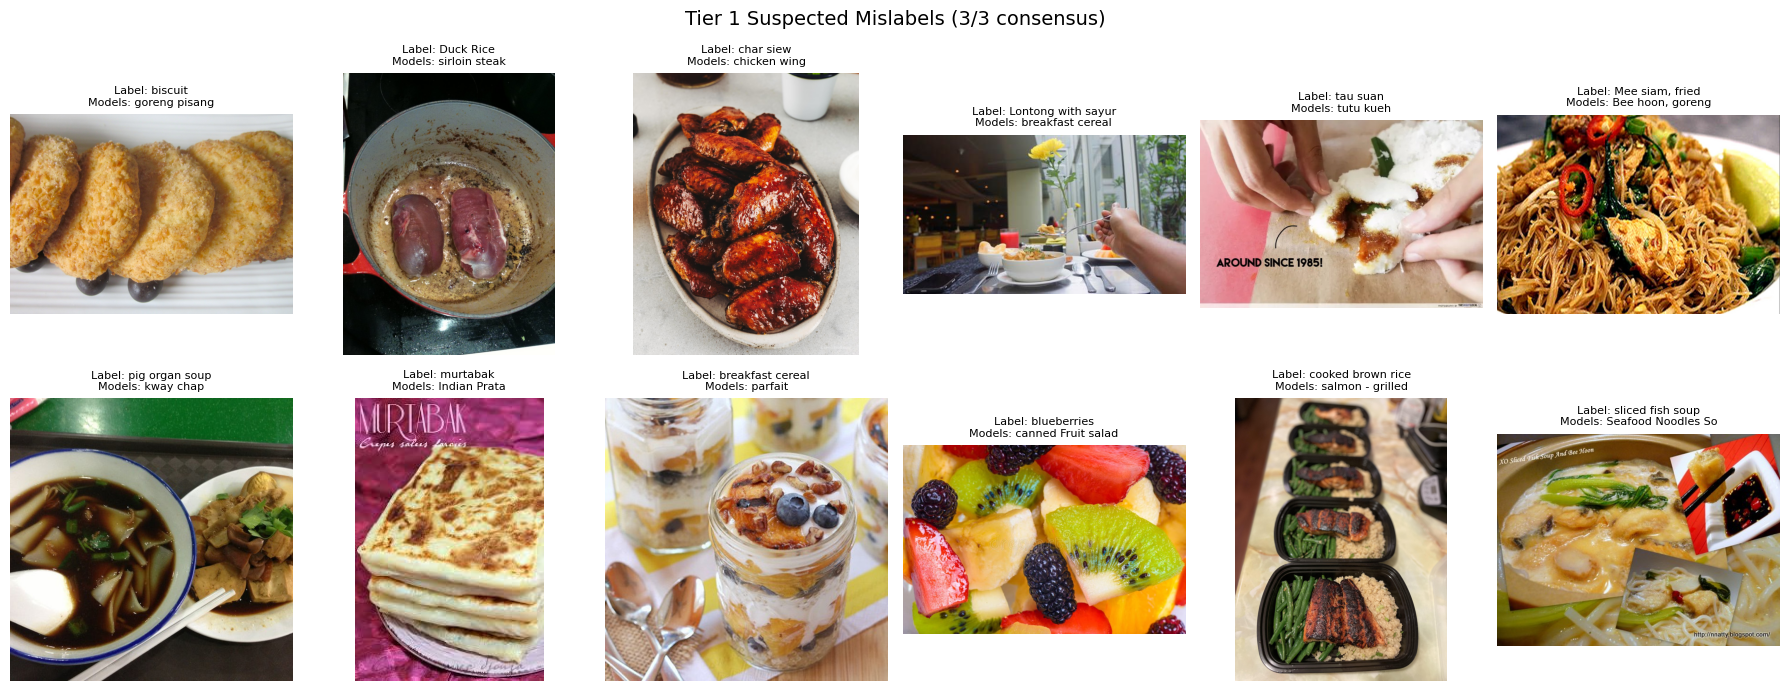

In [7]:
# ── Visualize sample of Tier 1 suspected mislabels ──
np.random.seed(42)
n_show = min(12, len(tier1_indices))
sample_idx = np.random.choice(len(tier1_indices), n_show, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for i, si in enumerate(sample_idx):
    idx = tier1_indices[si]
    img_path, _ = dataset_raw.samples[idx]
    img = Image.open(img_path).convert('RGB')

    gt_name = class_names[true_labels[idx]]
    pred_name = class_names[tier1_predicted[si]]

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {gt_name[:18]}\nModels: {pred_name[:18]}", fontsize=8)
    axes[i].axis('off')

# Hide unused subplots
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Tier 1 Suspected Mislabels (3/3 consensus)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# ── Generate CSVs for duplicate_reviewer.py ──
OUTPUT_DIR = Path("cleaning_results")
OUTPUT_DIR.mkdir(exist_ok=True)

def build_mislabel_df(indices, predicted_labels, num_agree_arr, confidence_arr):
    """Build a DataFrame with reviewer-compatible columns."""
    rows = []
    for i, idx in enumerate(indices):
        img_path, _ = dataset_raw.samples[idx]
        # Convert to relative path: ../foodsg-233_cleaned/ClassName/image.jpg
        img_path = Path(img_path)
        # Find parts after foodsg-233_cleaned
        parts = img_path.parts
        # Find index of 'foodsg-233_cleaned' in path
        try:
            root_idx = parts.index('foodsg-233_cleaned')
        except ValueError:
            # fallback: use last 3 parts (root/class/file)
            root_idx = len(parts) - 3
        rel_path = '../' + '/'.join(parts[root_idx:])

        gt_label = class_names[true_labels[idx]]
        pred_label = class_names[predicted_labels[i]]

        # Bidirectional confusion pair hash for grouping
        pair_key = '|'.join(sorted([gt_label, pred_label]))
        pair_hash = hashlib.md5(pair_key.encode()).hexdigest()

        num_agree = int(num_agree_arr[i]) if num_agree_arr is not None else 3
        conf = float(confidence_arr[i]) if confidence_arr is not None else 1.0

        rows.append({
            'path': rel_path,
            'label': gt_label,
            'split': 'all',
            'md5': pair_hash,
            'phash': pair_hash,
            'predicted_label': pred_label,
            'num_models_agree': num_agree,
            'convnext_confidence': round(conf, 4),
        })

    return pd.DataFrame(rows)

# Build Tier 1 DF
# For Tier 1, compute ConvNeXt confidence for the agreed-upon class
tier1_confidence = np.array([
    convnext_probs[idx, tier1_predicted[i]].item()
    for i, idx in enumerate(tier1_indices)
])
tier1_num_agree = np.full(len(tier1_indices), 3)

df_tier1 = build_mislabel_df(tier1_indices, tier1_predicted, tier1_num_agree, tier1_confidence)
df_tier2 = build_mislabel_df(tier2_indices, tier2_predicted, tier2_num_agree, tier2_confidence)

# Save initial CSVs
tier1_path = OUTPUT_DIR / "05a_mislabels_3of3_consensus.csv"
tier2_path = OUTPUT_DIR / "05b_mislabels_2of3_consensus.csv"
df_tier1.to_csv(tier1_path, index=False)
df_tier2.to_csv(tier2_path, index=False)

# Print group stats
for name, df, path in [("Tier 1", df_tier1, tier1_path), ("Tier 2", df_tier2, tier2_path)]:
    groups_md5 = df.groupby('md5').size()
    multi = (groups_md5 >= 2).sum()
    single = (groups_md5 == 1).sum()
    print(f"\n{name} ({path.name}):")
    print(f"  Total rows:                {len(df)}")
    print(f"  Groups with 2+ images:     {multi}")
    print(f"  Singleton groups:          {single}")


Tier 1 (05a_mislabels_3of3_consensus.csv):
  Total rows:                2217
  Groups with 2+ images:     344
  Singleton groups:          634

Tier 2 (05b_mislabels_2of3_consensus.csv):
  Total rows:                2293
  Groups with 2+ images:     350
  Singleton groups:          752


In [9]:
# ── Handle singleton groups + final summary ──
# The reviewer needs 2+ images per group. Singleton confusion pairs (only 1 image
# in that bidirectional pair) get re-hashed by their true class as a fallback,
# so they appear alongside other mislabels from the same class.

def fix_singletons(df):
    """Re-hash singleton groups by true class so reviewer can display them."""
    group_sizes = df.groupby('md5')['path'].transform('count')
    singleton_mask = group_sizes == 1

    if singleton_mask.sum() == 0:
        print("  No singletons to fix.")
        return df

    df = df.copy()
    # For singletons, hash by true class name instead of confusion pair
    for i in df.index[singleton_mask]:
        class_hash = hashlib.md5(f"mislabel_{df.at[i, 'label']}".encode()).hexdigest()
        df.at[i, 'md5'] = class_hash
        df.at[i, 'phash'] = class_hash

    # Check how many are still singletons after re-hashing
    new_sizes = df.groupby('md5')['path'].transform('count')
    still_single = (new_sizes == 1).sum()
    print(f"  Fixed {singleton_mask.sum()} singletons -> {still_single} remain as singletons")
    return df

print("Fixing singleton groups...")
print("\nTier 1:")
df_tier1 = fix_singletons(df_tier1)
print("\nTier 2:")
df_tier2 = fix_singletons(df_tier2)

# Overwrite CSVs with fixed grouping
df_tier1.to_csv(tier1_path, index=False)
df_tier2.to_csv(tier2_path, index=False)

# Final stats
for name, df, path in [("Tier 1", df_tier1, tier1_path), ("Tier 2", df_tier2, tier2_path)]:
    groups_md5 = df.groupby('md5').size()
    multi = (groups_md5 >= 2).sum()
    single = (groups_md5 == 1).sum()
    print(f"\n{name} final ({path.name}):")
    print(f"  Total rows:                {len(df)}")
    print(f"  Groups with 2+ images:     {multi}")
    print(f"  Singleton groups:          {single}")

print("\n" + "=" * 70)
print("DONE! To review suspected mislabels:")
print("=" * 70)
print("  cd food_classifier_project/cleaning_results")
print("  streamlit run duplicate_reviewer.py")
print("")
print("  In the sidebar, set:")
print(f"    Exact CSV  -> {tier1_path.name}")
print(f"    Near CSV   -> {tier2_path.name}")
print("")
print("  Use 'Cross-class only' filter to focus on the most informative groups.")

Fixing singleton groups...

Tier 1:
  Fixed 634 singletons -> 53 remain as singletons

Tier 2:
  Fixed 752 singletons -> 37 remain as singletons

Tier 1 final (05a_mislabels_3of3_consensus.csv):
  Total rows:                2217
  Groups with 2+ images:     495
  Singleton groups:          53

Tier 2 final (05b_mislabels_2of3_consensus.csv):
  Total rows:                2293
  Groups with 2+ images:     524
  Singleton groups:          37

DONE! To review suspected mislabels:
  cd food_classifier_project/cleaning_results
  streamlit run duplicate_reviewer.py

  In the sidebar, set:
    Exact CSV  -> 05a_mislabels_3of3_consensus.csv
    Near CSV   -> 05b_mislabels_2of3_consensus.csv

  Use 'Cross-class only' filter to focus on the most informative groups.


## Apply Tier 1 Review Decisions

After manually reviewing all 2,217 Tier 1 (3/3 consensus) suspected mislabels in the `mislabel_reviewer`, apply the decisions to the dataset:

- **Keep** (271): label is correct, no action needed
- **Remove** (650): delete the image (junk / ambiguous)
- **Relabel** (1,296): move image to the model-predicted class folder

After applying, the Tier 2 CSV (`05b`) is filtered to remove any entries whose files no longer exist on disk. Re-running the detection pipeline (cells 3-9) after this will naturally exclude all cleaned images since removed files are gone and relabeled files now have correct ground-truth labels.

In [10]:
# ── Apply Tier 1 review decisions and verify ──
import json as _json
import shutil

PROGRESS_PATH = Path("cleaning_results/mislabel_review_progress.json")
TIER2_CSV = Path("cleaning_results/05b_mislabels_2of3_consensus.csv")

# 1. Load review decisions
with open(PROGRESS_PATH) as f:
    progress = _json.load(f)

decisions = progress["decisions"]
print(f"Loaded {len(decisions)} Tier 1 review decisions\n")

keeps    = {k: v for k, v in decisions.items() if v["action"] == "keep"}
removes  = {k: v for k, v in decisions.items() if v["action"] == "remove"}
relabels = {k: v for k, v in decisions.items() if v["action"] == "relabel"}
print(f"  Keep:    {len(keeps):>5}")
print(f"  Remove:  {len(removes):>5}")
print(f"  Relabel: {len(relabels):>5}")

# Resolve paths relative to this notebook (food_classifier_project/)
BASE_DIR = Path(".").resolve()

def resolve_path(rel_path):
    return (BASE_DIR / rel_path.replace("\\", "/")).resolve()

# ── Apply removals ──
print(f"\n{'='*60}")
print(f"Applying {len(removes)} removals...")
rm_ok = rm_gone = 0
rm_errors = []

for dec in removes.values():
    fp = resolve_path(dec["path"])
    if not fp.exists():
        rm_gone += 1
    else:
        try:
            fp.unlink()
            rm_ok += 1
        except Exception as e:
            rm_errors.append(str(e))

print(f"  Deleted:      {rm_ok}")
print(f"  Already gone: {rm_gone}")
if rm_errors:
    print(f"  Errors:       {len(rm_errors)}")
    for e in rm_errors[:5]:
        print(f"    {e}")

# ── Apply relabels ──
print(f"\nApplying {len(relabels)} relabels...")
rl_ok = rl_gone = 0
rl_errors = []

for dec in relabels.values():
    fp = resolve_path(dec["path"])
    pred = dec["predicted_label"]

    if not fp.exists():
        rl_gone += 1
        continue

    # Move to new class folder: .../foodsg-233_cleaned/<pred>/filename
    parts = fp.parts
    root_idx = next((i for i, p in enumerate(parts) if "foodsg-233_cleaned" in p), None)
    if root_idx is None:
        rl_errors.append(f"No dataset root in {dec['path']}")
        continue

    target_dir = Path(*parts[:root_idx + 1]) / pred
    target_dir.mkdir(parents=True, exist_ok=True)
    target_path = target_dir / fp.name

    try:
        shutil.move(str(fp), str(target_path))
        rl_ok += 1
    except Exception as e:
        rl_errors.append(str(e))

print(f"  Moved:        {rl_ok}")
print(f"  Already gone: {rl_gone}")
if rl_errors:
    print(f"  Errors:       {len(rl_errors)}")
    for e in rl_errors[:5]:
        print(f"    {e}")

# ── Verify ──
print(f"\n{'='*60}")
print("VERIFICATION")
print(f"{'='*60}")

still_there = sum(1 for d in removes.values() if resolve_path(d["path"]).exists())
print(f"  Removed files still on disk:  {still_there} (expect 0)")

at_new = at_old = 0
for dec in relabels.values():
    old_fp = resolve_path(dec["path"])
    parts = old_fp.parts
    root_idx = next((i for i, p in enumerate(parts) if "foodsg-233_cleaned" in p), None)
    if root_idx:
        new_fp = Path(*parts[:root_idx + 1]) / dec["predicted_label"] / old_fp.name
        at_new += new_fp.exists()
        at_old += old_fp.exists()

print(f"  Relabels at new location:     {at_new} / {len(relabels)}")
print(f"  Relabels still at old path:   {at_old} (expect 0)")

# ── Update Tier 2 CSV: remove stale entries ──
print(f"\n{'='*60}")
print("Updating Tier 2 (05b) CSV — removing stale paths...")
print(f"{'='*60}")

df_t2 = pd.read_csv(TIER2_CSV)
before_t2 = len(df_t2)

# Drop rows whose image file no longer exists on disk
exists_mask = df_t2["path"].apply(lambda p: resolve_path(p).exists())
df_t2 = df_t2[exists_mask].reset_index(drop=True)
dropped = before_t2 - len(df_t2)
df_t2.to_csv(TIER2_CSV, index=False)

print(f"  Before:  {before_t2} rows")
print(f"  Dropped: {dropped} (paths no longer on disk)")
print(f"  After:   {len(df_t2)} rows")

# ── Final dataset stats ──
print(f"\n{'='*60}")
print("DATASET AFTER TIER 1 CLEANING")
print(f"{'='*60}")

dataset_after = ImageFolder(CLEANED_ROOT)
print(f"  Before:          {len(dataset):>7,} images")
print(f"  After:           {len(dataset_after):>7,} images")
print(f"  Net change:      {len(dataset_after) - len(dataset):>+7,}")
print(f"  Classes:         {len(dataset_after.classes):>7}")
print(f"\n  Breakdown:")
print(f"    Removed:       {len(removes):>5} images deleted")
print(f"    Relabeled:     {len(relabels):>5} images moved to correct class")
print(f"    Kept:          {len(keeps):>5} labels confirmed correct")
print(f"\nTier 1 cleaning complete. Re-running cells 3-9 will not re-flag these images.")

Loaded 2217 Tier 1 review decisions

  Keep:      271
  Remove:    650
  Relabel:  1296

Applying 650 removals...
  Deleted:      650
  Already gone: 0

Applying 1296 relabels...
  Moved:        1296
  Already gone: 0

VERIFICATION
  Removed files still on disk:  0 (expect 0)
  Relabels at new location:     1296 / 1296
  Relabels still at old path:   0 (expect 0)

Updating Tier 2 (05b) CSV — removing stale paths...
  Before:  2293 rows
  Dropped: 0 (paths no longer on disk)
  After:   2293 rows

DATASET AFTER TIER 1 CLEANING
  Before:          204,305 images
  After:           203,655 images
  Net change:         -650
  Classes:             233

  Breakdown:
    Removed:         650 images deleted
    Relabeled:      1296 images moved to correct class
    Kept:            271 labels confirmed correct

Tier 1 cleaning complete. Re-running cells 3-9 will not re-flag these images.


In [11]:
# ── Current dataset size ──
from torchvision.datasets import ImageFolder

current_dataset = ImageFolder(CLEANED_ROOT)
print(f"Current dataset: {len(current_dataset):,} images across {len(current_dataset.classes)} classes")

Current dataset: 203,655 images across 233 classes


## Layer 1: Impact of Label Correction on Evaluation

**Goal**: Measure how much accuracy improves *without retraining* — just by fixing the ground-truth labels.

The models were trained on the original dirty dataset (204,305 images). Cell 4 evaluated them on that same dirty dataset. Now we re-evaluate the **same checkpoints** on the cleaned dataset (203,655 images) where 650 junk images have been removed and 1,296 mislabeled images moved to the correct class folder.

Any accuracy increase here is purely from correcting the evaluation labels — the model weights haven't changed.

In [12]:
# ── Layer 1: Re-evaluate same checkpoints on cleaned dataset ──
# The models haven't changed — only the ground-truth labels have been fixed.
# Old accuracies (from cell 4, on 204,305 dirty images):
#   ResNet50:  81.91%
#   ViT:       94.95%
#   ConvNeXt:  95.81%

# Load fresh dataset (cleaned: 203,655 images)
clean_transforms = get_val_transforms()
clean_dataset = ImageFolder(CLEANED_ROOT, transform=clean_transforms)

assert clean_dataset.classes == class_names, "Class ordering mismatch after cleaning!"

clean_loader = DataLoader(
    clean_dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)
print(f"Clean dataset: {len(clean_dataset):,} images, {len(clean_loader)} batches\n")

# Run inference with all 3 models on the cleaned dataset
old_accuracies = {
    'CNN (ResNet50)': 0.8191,
    'ViT':           0.9495,
    'ConvNeXt':      0.9581,
}

new_accuracies = {}
for name, model in models.items():
    print(f"Running {name} on cleaned dataset...")
    preds, labels, _ = get_all_predictions(model, clean_loader, device)
    acc = (preds == labels).mean()
    new_accuracies[name] = acc
    print(f"  Accuracy: {acc:.4f}\n")

# ── Before/After comparison ──
print("=" * 70)
print("LAYER 1: IMPACT OF LABEL CORRECTION (no retraining)")
print("=" * 70)
print(f"{'Model':<20s} {'Dirty (204,305)':<18s} {'Clean (203,655)':<18s} {'Change':<10s}")
print("-" * 70)

for name in models:
    old = old_accuracies[name]
    new = new_accuracies[name]
    delta = new - old
    print(f"{name:<20s} {old:>13.2%}     {new:>13.2%}     {delta:>+7.2%}")

print("-" * 70)
print(f"\nAll accuracy gains are purely from fixing ground-truth labels.")
print(f"Images removed: 650 | Images relabeled: 1,296")

Clean dataset: 203,655 images, 3183 batches

Running CNN (ResNet50) on cleaned dataset...


Predicting:   0%|          | 0/3183 [00:16<?, ?it/s]

  Accuracy: 0.8280

Running ViT on cleaned dataset...


Predicting:   0%|          | 0/3183 [00:12<?, ?it/s]

  Accuracy: 0.9589

Running ConvNeXt on cleaned dataset...


Predicting:   0%|          | 0/3183 [00:11<?, ?it/s]

  Accuracy: 0.9675

LAYER 1: IMPACT OF LABEL CORRECTION (no retraining)
Model                Dirty (204,305)    Clean (203,655)    Change    
----------------------------------------------------------------------
CNN (ResNet50)              81.91%            82.80%      +0.89%
ViT                         94.95%            95.89%      +0.94%
ConvNeXt                    95.81%            96.75%      +0.94%
----------------------------------------------------------------------

All accuracy gains are purely from fixing ground-truth labels.
Images removed: 650 | Images relabeled: 1,296


## Re-create Train/Val/Test Splits

Tier 1 mislabel cleaning is complete (650 removed, 1,296 relabeled). The old split directories are now stale. Re-create fresh 75/15/10 splits from the cleaned dataset (203,655 images).

In [13]:
import os
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

def create_splits(source_dir, output_dir, train_ratio=0.75, val_ratio=0.15, seed=42):
    """
    Split dataset into train/val/test.
    
    Args:
        source_dir: Folder with class subfolders containing images
        output_dir: Where to create train/val/test structure
        train_ratio: Proportion for training (default 75%)
        val_ratio: Proportion for validation (default 15%)
        seed: Random seed for reproducibility
    """
    test_ratio = 1 - train_ratio - val_ratio
    
    # Collect all images by class
    class_images = defaultdict(list)
    for class_name in os.listdir(source_dir):
        class_dir = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                class_images[class_name].append(img_name)
    
    print(f"Found {len(class_images)} classes")
    
    # Create output directories
    for split in ['train', 'val', 'test']:
        for class_name in class_images.keys():
            os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)
    
    # Split each class (stratified)
    for class_name, images in class_images.items():
        # First split: train vs (val+test)
        train_imgs, temp_imgs = train_test_split(
            images, 
            train_size=train_ratio, 
            random_state=seed
        )
        
        # Second split: val vs test
        val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
        val_imgs, test_imgs = train_test_split(
            temp_imgs, 
            train_size=val_ratio_adjusted, 
            random_state=seed
        )
        
        # Copy files
        for img in train_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'train', class_name, img)
            shutil.copy2(src, dst)
        
        for img in val_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'val', class_name, img)
            shutil.copy2(src, dst)
        
        for img in test_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'test', class_name, img)
            shutil.copy2(src, dst)
        
        print(f"{class_name}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test")
    
    print("\nDone!")

# Run the split
create_splits("../foodsg-233_cleaned", "../foodsg-233_train_val_test_split", train_ratio=0.75, val_ratio=0.15)

Found 233 classes
Alcoholic Beverage: 574 train, 115 val, 77 test
Apple: 482 train, 96 val, 65 test
Apricot: 315 train, 63 val, 43 test
assam pedas: 480 train, 96 val, 65 test
Avocados: 420 train, 84 val, 56 test
ayam penyet: 450 train, 90 val, 60 test
bagel & croissant: 356 train, 71 val, 48 test
bak chor mee: 642 train, 128 val, 86 test
bak kut teh: 546 train, 109 val, 74 test
bak kwa: 557 train, 111 val, 75 test
baked beans: 789 train, 157 val, 106 test
bakso: 523 train, 105 val, 70 test
Ban Mian: 348 train, 69 val, 47 test
banana: 993 train, 198 val, 133 test
Barley: 297 train, 60 val, 40 test
bee hoon: 475 train, 95 val, 64 test
Bee hoon, goreng: 942 train, 188 val, 126 test
Bee hoon, soto: 462 train, 93 val, 62 test
beef noodle soup: 652 train, 130 val, 88 test
begedil: 597 train, 119 val, 80 test
Bibimbap: 771 train, 154 val, 103 test
biscuit: 2174 train, 435 val, 290 test
black pepper crab: 429 train, 86 val, 58 test
Blackberry: 388 train, 78 val, 52 test
blueberries: 825 train

In [14]:
# ── Verify new splits ──
SPLIT_ROOT = "../foodsg-233_train_val_test_split"

total = 0
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(SPLIT_ROOT, split)
    classes = sorted(os.listdir(split_dir))
    count = sum(
        len([f for f in os.listdir(os.path.join(split_dir, c))
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
        for c in classes if os.path.isdir(os.path.join(split_dir, c))
    )
    total += count
    print(f"{split:5s}: {count:>7,} images | {len(classes)} classes")

print(f"{'total':5s}: {total:>7,} images")
print(f"\nExpected: 203,655")
print(f"Match:    {'YES' if total == 203_655 else 'NO — mismatch!'}")

train: 152,657 images | 233 classes
val  :  30,511 images | 233 classes
test :  20,487 images | 233 classes
total: 203,655 images

Expected: 203,655
Match:    YES
